https://contest.yandex.ru/contest/28413/problems/

In [1]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt

In [3]:
def generate1():
    a = random.uniform(0, 1)
    b = random.uniform(0, 1)
    return (a * math.cos(2 * math.pi * b), a * math.sin(2 * math.pi * b))

def generate2():
    while True:
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x ** 2 + y ** 2 > 1:
            continue
        return (x, y)

Главный индикатор - распределение радиуса

In [11]:
p1 = [generate1() for _ in range(1000)]
x1, y1 = zip(*p1)
r1 = np.sqrt(np.array(x1) ** 2 + np.array(y1) ** 2)
p2 = [generate2() for _ in range(1000)]
x2, y2 = zip(*p2)
r2 = np.sqrt(np.array(x2) ** 2 + np.array(y2) ** 2)

(array([ 90., 108., 105.,  91., 112., 106., 100.,  99.,  91.,  98.]),
 array([0.00121691, 0.10107021, 0.20092351, 0.30077681, 0.40063012,
        0.50048342, 0.60033672, 0.70019002, 0.80004333, 0.89989663,
        0.99974993]),
 <BarContainer object of 10 artists>)

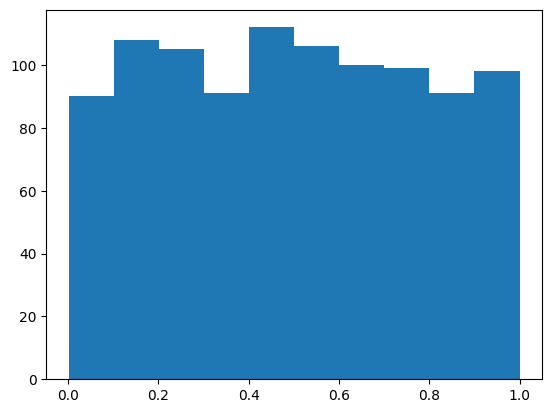

In [14]:
plt.hist(r1)

r1 похоже на равномерное

(array([ 28.,  28.,  63.,  63.,  96., 102., 105., 146., 175., 194.]),
 array([0.04429848, 0.13969831, 0.23509814, 0.33049798, 0.42589781,
        0.52129764, 0.61669748, 0.71209731, 0.80749715, 0.90289698,
        0.99829681]),
 <BarContainer object of 10 artists>)

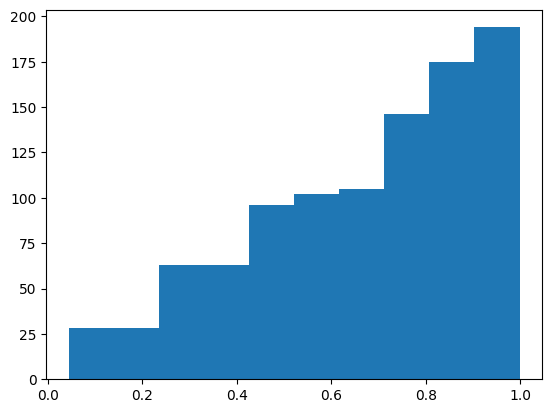

In [13]:
plt.hist(r2)

r2 скошено вправо

In [19]:
np.mean(r1)

0.4968209992044454

In [21]:
np.mean(r2)

0.6698856045157547

Надо просто подобрать порог (можно было бы решить с помощью ML, но боюсь не хватит времени)

In [7]:
means1 = []
means2 = []
for i in range(1000):
    p1 = [generate1() for _ in range(1000)]
    x1, y1 = zip(*p1)
    r1 = np.sqrt(np.array(x1) ** 2 + np.array(y1) ** 2)
    p2 = [generate2() for _ in range(1000)]
    x2, y2 = zip(*p2)
    r2 = np.sqrt(np.array(x2) ** 2 + np.array(y2) ** 2)    


    means1.append(np.mean(r1))
    means2.append(np.mean(r2))

print('Mean 1:', np.mean(means1))
print('Mean 2:', np.mean(means2))
print('Max ', np.max(means1))
print('Min ', np.min(means2))

Mean 1: 0.5005187237574555
Mean 2: 0.6665955223521034
Max  0.5338317431969026
Min  0.6406420340002367


threshold is 0.64
if mean < threshold:
    print(1)
else: 
    print(2)

## Решение

In [ ]:
import numpy as np
threshold = 0.64
for i in range(100):
    p = np.fromstring(input(), dtype=float, sep=' ') 
    x = p[0::2]
    y = p[1::2]    

    r = np.sqrt(x ** 2 + y ** 2)
    r_mean = np.mean(r)
    if r_mean < threshold:
        print(1)
    else:
        print(2)
       